In [21]:
!pip install cufflinks

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for cufflinks: filename=cufflinks-0.17.3-py3-none-any.whl size=68794 sha256=df962e32c69b924239fcb8d02d5e96348a0f8adb1c8e02bac0a1f16fc1be2319
  Stored in directory: c:\users\admin\appdata\local\pip\cache\wheels\09\8a\6b\cbe3e87b2e59bb5f90b49b034ce36b80b46a4d6e38444c34de
Successfully built cufflinks


## Step-1 Import the libraries

In [64]:
import io
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

from itertools import product
from scipy.stats import chi2_contingency



In [ ]:
#Basic libraries
import pandas as pd
import numpy as np

#Visualization libraries
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
from plotly import tools
from plotly.offline import iplot

#Geospatial Analysis Libraries
import geopandas as gpd
import math
import folium
from folium import Choropleth, Circle, Marker
from folium.plugins import HeatMap, MarkerCluster



## Step-2 Load the Dataset

In [26]:
file_name = r'E:\Z_Arise\ML_Lab\Ex_1(b)_EDA\onlinedeliverydata.csv'

data = pd.read_csv(file_name)
data.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,...,Less Delivery time,High Quality of package,Number of calls,Politeness,Freshness,Temperature,Good Taste,Good Quantity,Output,Reviews
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,...,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Yes,Nil\n
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,...,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Yes,Nil
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,...,Important,Very Important,Moderately Important,Very Important,Very Important,Important,Very Important,Moderately Important,Yes,"Many a times payment gateways are an issue, so..."
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,...,Very Important,Important,Moderately Important,Very Important,Very Important,Very Important,Very Important,Important,Yes,nil
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,...,Important,Important,Moderately Important,Important,Important,Important,Very Important,Very Important,Yes,NIL


### Insights

We can understand that there are more categorical variables and very less continuous variables
There is also longitude and latitude variable which can help us for geospatial analysis
Most of the variables has likert scale classes inside the variable , it needs to be encoded

## Step-3 Analyze the dataset

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 55 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Age                                        388 non-null    int64  
 1   Gender                                     388 non-null    object 
 2   Marital Status                             388 non-null    object 
 3   Occupation                                 388 non-null    object 
 4   Monthly Income                             388 non-null    object 
 5   Educational Qualifications                 388 non-null    object 
 6   Family size                                388 non-null    int64  
 7   latitude                                   388 non-null    float64
 8   longitude                                  388 non-null    float64
 9   Pin code                                   388 non-null    int64  
 10  Medium (P1)               

#### Content of dataset
The dataset has nearly 55 variables based on the following titles

Demographics of consumers
Overall/general purchase decision
Time of delivery influencing the purchase decision
Rating of Restaurant influencing the purchase decision
For more information on each columns check out the description provided below head column title

In [10]:
data.describe()

,Age,Family size,latitude,longitude,Pin code
count,388.000000,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160,560040.113402
std,2.975593,1.351025,0.044489,0.051354,31.399609
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.936900,77.565275,560010.750000
50%,24.000000,3.000000,12.977000,77.592100,560033.500000
75%,26.000000,4.000000,12.997025,77.630900,560068.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


### Insights:

#### We have 388 respondents(records) in our dataset
#### Age of the respondents vary between 18-33 with an average of 25
#### Family size of respondents vary between 1-6 with an average of 3
#### Lat, Long and Pincode shouldn't be considered for the numerical variable as they don't provide    much values from such measures.

Even before moving on to the data visualization step, we can see that some form of dimensionality reduction will be required to avoid overfitting when we fit the model on this data. In the next steps we will see how we can do it.

In [68]:
data.isnull()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,...,Less Delivery time,High Quality of package,Number of calls,Politeness,Freshness,Temperature,Good Taste,Good Quantity,Output,Reviews
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
384,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
385,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
386,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Demographic analysis 1

In [35]:
#Pivot table
delivery_pivot1=pd.pivot_table(data,index=["Gender","Marital Status"],
                               values=['Age','Family size'],
                               #aggfunc=[np.mean,len]
                               aggfunc = ['mean'], margins=True)

#Adding color gradient 
cm = sns.light_palette("green", as_cmap=True)
delivery_pivot1.style.background_gradient(cmap=cm)

### Insights:

#### Average age of female, male and single is around 23 and 27,28 for married female and male respectively
#### Average family size is 4 for a female respondent and 3 for male.
#### There are more male respondents(bachelor/married) than in the case of female

## Demographic analysis 2

In [ ]:
#Pivot table
delivery_pivot2=pd.pivot_table(data,index=["Educational Qualifications","Occupation"],
                               values=['Age','Family size'],
                               # aggfunc=[np.mean,len,np.std])
                               aggfunc = ['mean',len,'std'])

#Adding bar for numbers
delivery_pivot2.style.bar()

### 📊 Key Insights: Demographic & Employment Analysis

* **Education & Domestic Roles:** Female respondents with only school-level education or no formal education are primarily **Housewives**. On average, these individuals tend to be older than the rest of the respondent pool.
* **Self-Employment Trends:** There is a distinct correlation between a lack of formal education and entrepreneurship, as the majority of **Uneducated** individuals are **Self-Employed**.
* **The Academic-Career Path:** **Graduates and Ph.D. holders** show the highest employment rates. However, a large portion of this demographic is still identified as **Students**, suggesting a long-term commitment to higher education before transitioning fully into the workforce.
* **Analysis of Volatility (Standard Deviation):**
    * **School-Educated:** This group shows a high standard deviation, reflecting significant **career uncertainty** and a wide variety of life paths for those who do not pursue higher education.
    * **Employed Ph.D.s:** High deviation in this group likely indicates a broad range of ages or diverse professional levels within specialized fields.

## Univaritive Analysis

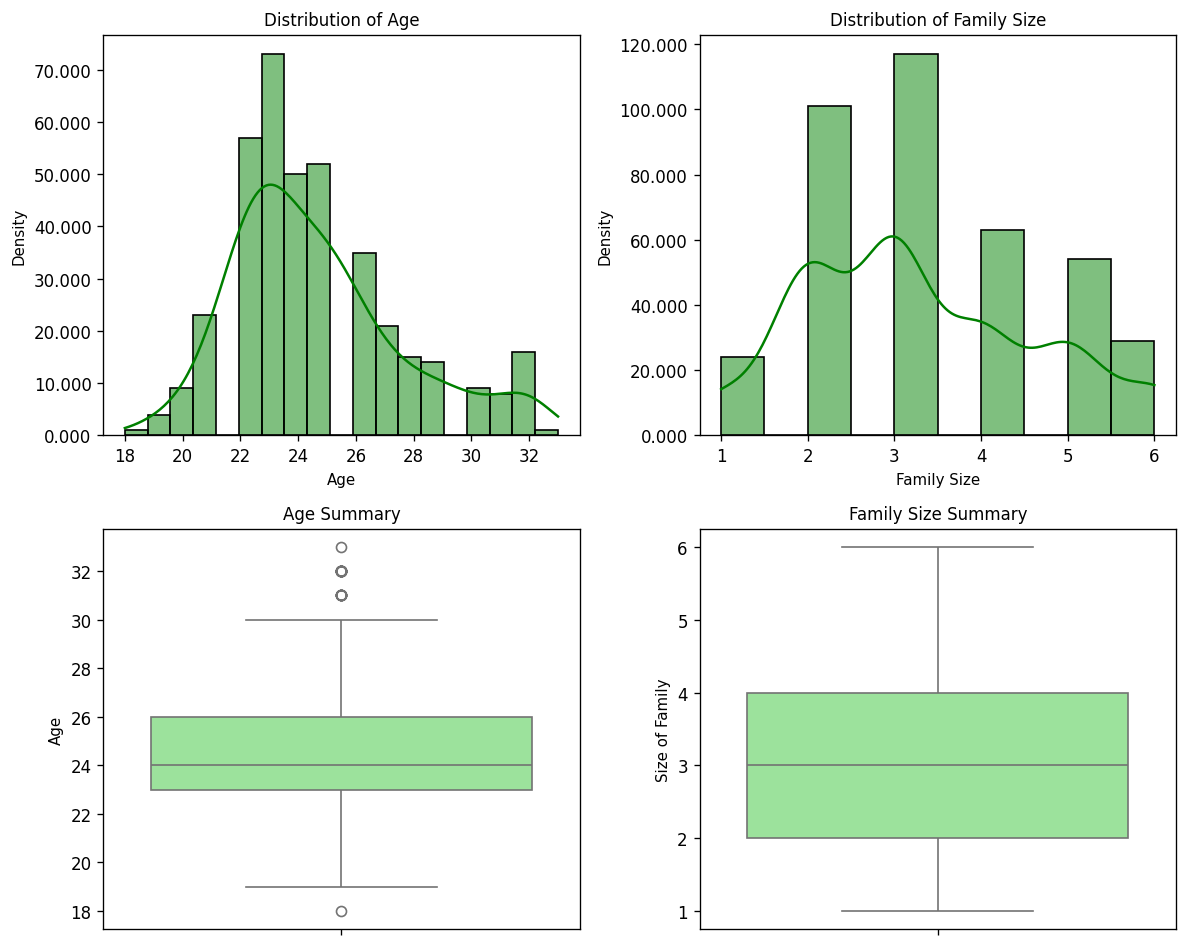

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

# Setting up the frame
fig, axes = plt.subplots(nrows=2, ncols=2, dpi=120, figsize=(10, 8))

# --- 1. Age Distribution (Top Left) ---
# Using histplot with kde=True replaces distplot
sns.histplot(data=data, x='Age', kde=True, ax=axes[0][0], color='green')
axes[0][0].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
axes[0][0].set_title('Distribution of Age', fontsize=10)
axes[0][0].set_xlabel('Age', fontsize=9)
axes[0][0].set_ylabel('Density', fontsize=9)

# --- 2. Family Size Distribution (Top Right) ---
sns.histplot(data=data, x='Family size', kde=True, ax=axes[0][1], color='green')
axes[0][1].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
axes[0][1].set_title('Distribution of Family Size', fontsize=10)
axes[0][1].set_xlabel('Family Size', fontsize=9)
axes[0][1].set_ylabel('Density', fontsize=9)

# --- 3. Age Boxplot (Bottom Left) ---
# Explicitly setting y='Age' for a vertical boxplot
sns.boxplot(data=data, y='Age', ax=axes[1][0], color='lightgreen')
axes[1][0].set_title('Age Summary', fontsize=10)
axes[1][0].set_ylabel('Age', fontsize=9)

# --- 4. Family Size Boxplot (Bottom Right) ---
sns.boxplot(data=data, y='Family size', ax=axes[1][1], color='lightgreen')
axes[1][1].set_title('Family Size Summary', fontsize=10)
axes[1][1].set_ylabel('Size of Family', fontsize=9)

# Final cleanup
plt.tight_layout()
plt.show()

## Geospatial Analysis
### Geo Painter

In [53]:
Age_band = data[(data.Age.isin(range(18,40)))]
# Creating a map
m_2 = folium.Map(location=[12.9716,77.5946], tiles='cartodbpositron', zoom_start=13)

# Adding points to the map
for idx, row in Age_band.iterrows():
    Marker([row['latitude'], row['longitude']]).add_to(m_2)

# Displaying the map
m_2




## Feature Correlation

In [59]:
# Change some features value to number, so we can plot it
data = data.replace(['0', '<10k', '10k-25k', '25k-50k', '>50k'], [1,2,3,4,5])
data = data.replace(['15 minutes', '30 minutes', '45 minutes', '60 minutes', 'more than 60 minutes'], [1,2,3,4,5])
trans_col = ['Gender', 'Marital Status', 'Occupation','Educational Qualifications','Medium (P1)', 
             'Medium (P2)', 'Meal(P1)', 'Meal(P2)', 'Perference(P1)', 'Perference(P2)']
for col in trans_col:
    data[col] = LabelEncoder().fit_transform(data[col])

<Figure size 2000x1500 with 0 Axes>

<Figure size 2000x1500 with 0 Axes>

<Figure size 2000x1500 with 0 Axes>

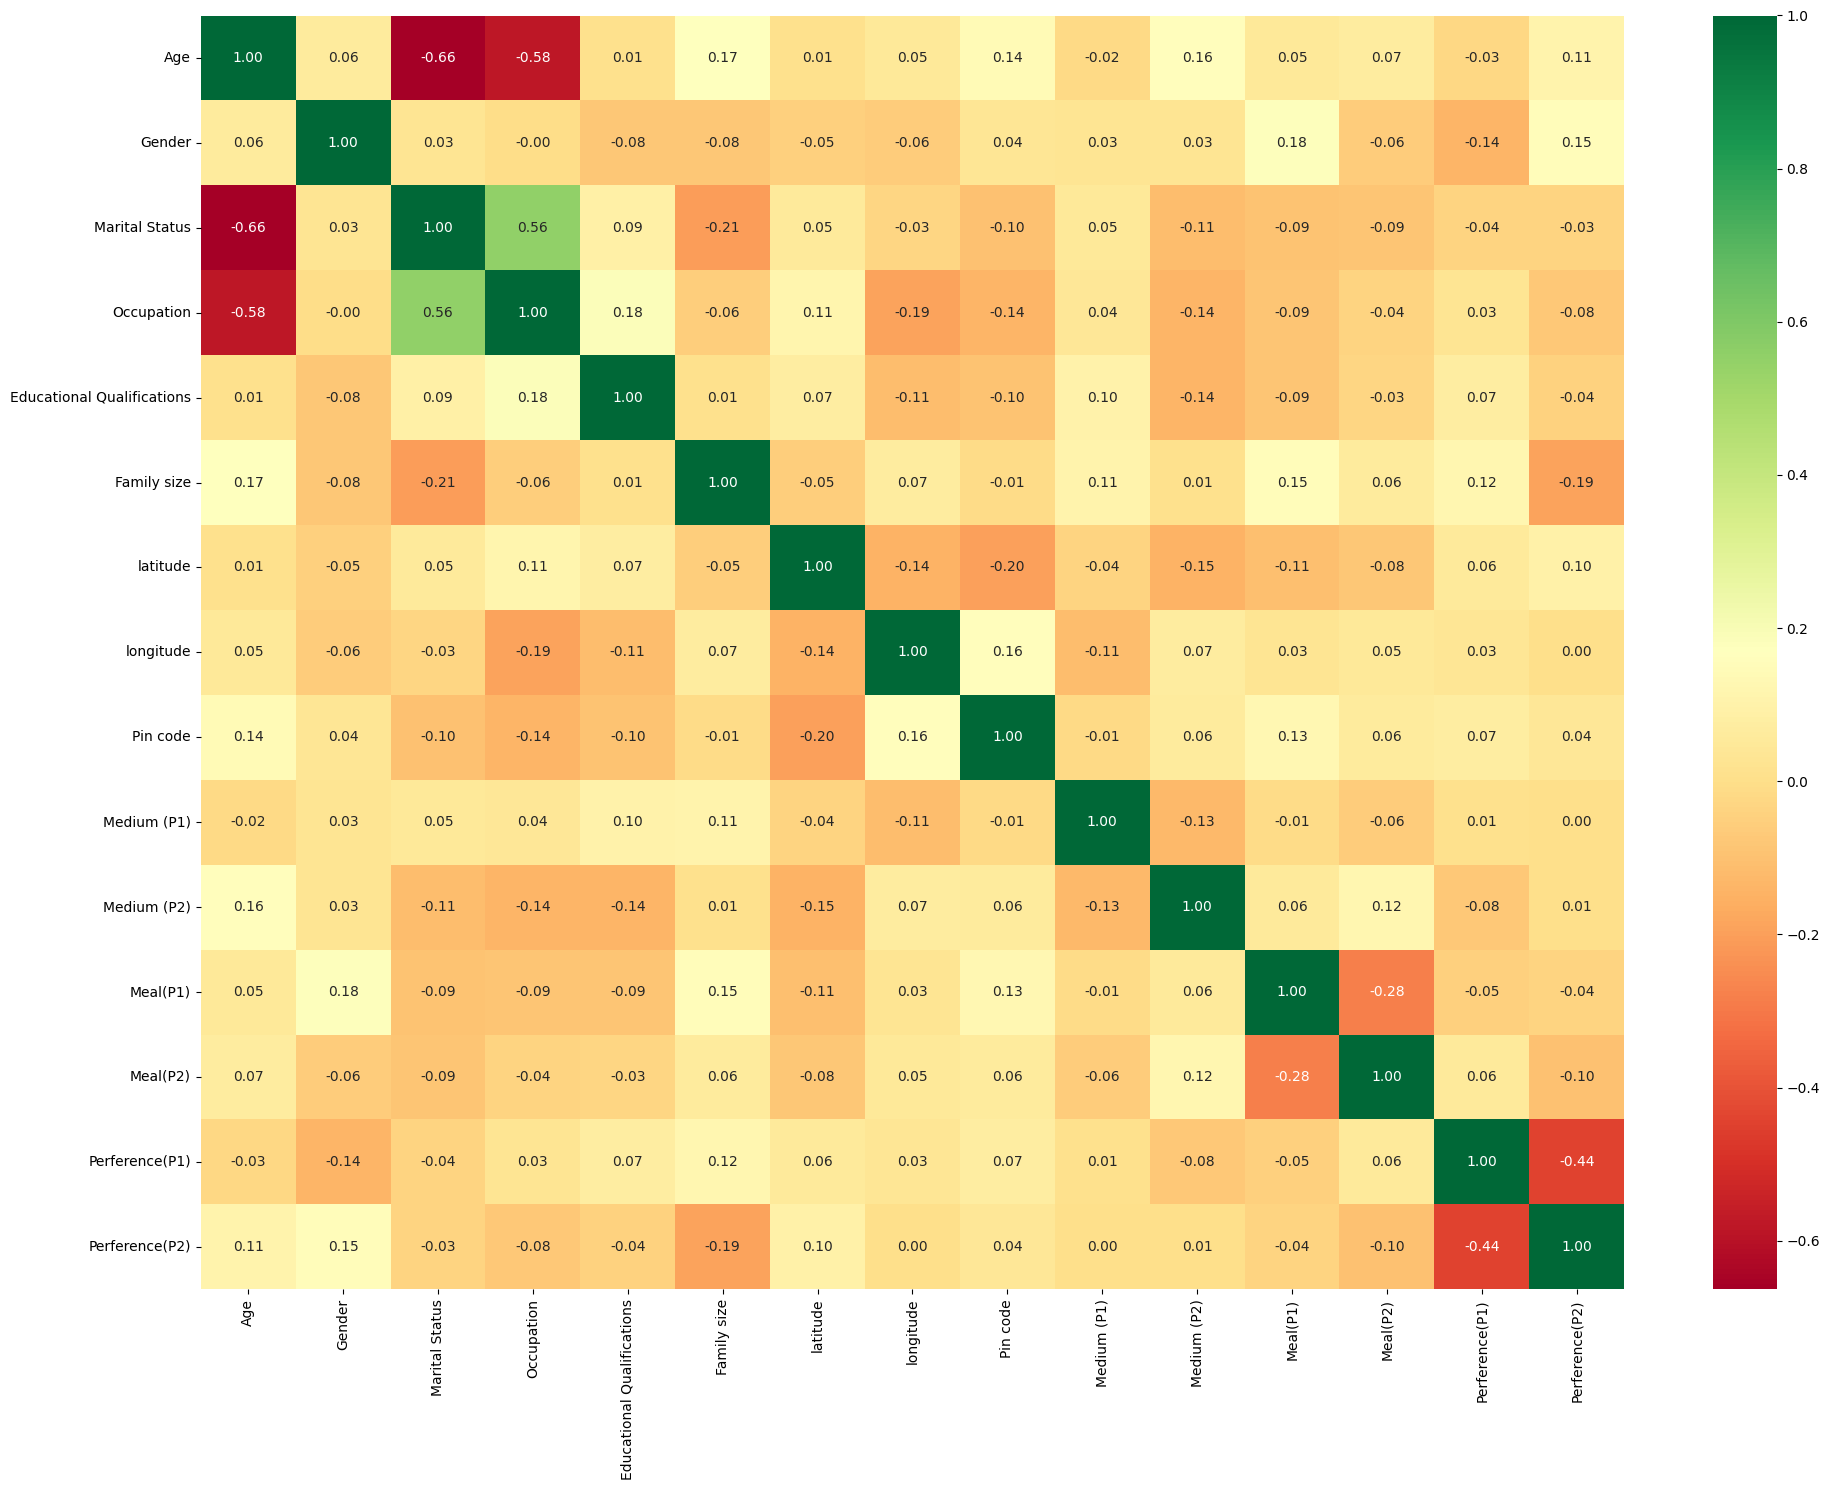

In [63]:
plt.figure(figsize=(20,15))
# The fix: Add numeric_only=True
corr_matrix = data.corr(method='pearson', numeric_only=True)

# Generate the heatmap with annotations and a nice color map
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.tight_layout()
plt.show()